# Dataset helper functions

In [19]:
import kagglehub
path = kagglehub.dataset_download("gpreda/chinese-mnist")
print("Path to dataset files:", path)

import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
import os

# this class construction codes are obtained from https://www.kaggle.com/code/tomasrando/perceptron-multicapa-con-dropout
# thank Tomas Rando for sharing his work
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class ChineseNumbersDataset(Dataset):
    def __init__(self, data, img_dir, transform=None):
        self.data = data
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_name = f"input_{row['suite_id']}_{row['sample_id']}_{row['code']}.jpg"
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform: 
            image = self.transform(image)

        label = int(row['code']) - 1

        return image, label



# # since three channels are all the same...only use one channel
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),        # a tensor
    transforms.Normalize((0.5,), (0.5,)) # normalizar
])


Path to dataset files: /home2/jianhuang/.cache/kagglehub/datasets/gpreda/chinese-mnist/versions/7


In [20]:
df = pd.read_csv(os.path.join(path, "chinese_mnist.csv"))
print("\n Snip \n")
print(df.head())
print("\n Description \n")
print(df.info())
print("\n CLASSES \n")
print(df['value'].unique())
print(len(df['value'].unique()))

# dataset = ChineseNumbersDataset(df, os.path.join(path, "data/data/"), transform = transform)


 Snip 

   suite_id  sample_id  code  value character
0         1          1    10      9         九
1         1         10    10      9         九
2         1          2    10      9         九
3         1          3    10      9         九
4         1          4    10      9         九

 Description 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   suite_id   15000 non-null  int64 
 1   sample_id  15000 non-null  int64 
 2   code       15000 non-null  int64 
 3   value      15000 non-null  int64 
 4   character  15000 non-null  object
dtypes: int64(4), object(1)
memory usage: 586.1+ KB
None

 CLASSES 

[        9        10       100      1000     10000 100000000         0
         1         2         3         4         5         6         7
         8]
15


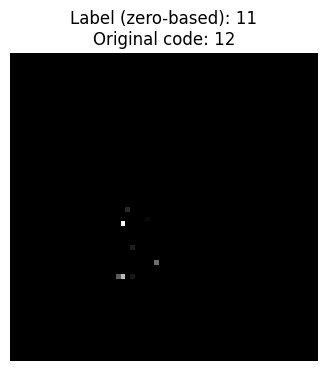

In [21]:
img_dir = os.path.join(path, "data/data/")
dataset = ChineseNumbersDataset(df, img_dir, transform=transform)

# pick any index you want to inspect
idx = 2957

image_tensor, label_tensor = dataset[idx]  # <-- uses __getitem__
label = label_tensor
img = image_tensor.clone()

if image_tensor.ndim == 3:
    # img = img * std[:, None, None] + mean[:, None, None]  # unnormalize
    img = img.permute(1, 2, 0).cpu().numpy()  # (H, W, C)
# else:
    # raise ValueError("Expected a 3D tensor (C, H, W)")

plt.figure(figsize=(4, 4))
plt.imshow(img.clip(0, 1), cmap="gray")  # clip in case of slight float errors
plt.axis("off")
plt.title(f"Label (zero-based): {label}\nOriginal code: {label + 1}")
plt.show()

In [4]:
df[(df['suite_id'] == 20) & (df['sample_id'] == 5)]

,suite_id,sample_id,code,value,character
135,20,5,10,9,九
1135,20,5,11,10,十
2135,20,5,12,100,百
3135,20,5,13,1000,千
4135,20,5,14,10000,万
5135,20,5,15,100000000,亿
6135,20,5,1,0,零
7135,20,5,2,1,一
8135,20,5,3,2,二
9135,20,5,4,3,三


In [5]:
image_tensor.shape

torch.Size([1, 64, 64])

In [6]:
image_tensor

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

# Generate dataset for downstream training

In [22]:
from sklearn.model_selection import train_test_split

df["label"] = df["code"] - 1

# 1) Train + temp split
train_df, temp_df = train_test_split(
    df, 
    test_size=0.3,            # 70% train, 30% temp
    stratify=df["label"], 
    random_state=42
)

# 2) Split temp into validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,            # half of the remainder
    stratify=temp_df["label"],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))


10500 2250 2250


In [23]:
img_dir = os.path.join(path, "data/data/")
train_dataset = ChineseNumbersDataset(train_df, img_dir, transform=transform)
val_dataset   = ChineseNumbersDataset(val_df,   img_dir, transform=transform)
test_dataset  = ChineseNumbersDataset(test_df,  img_dir, transform=transform)

In [1]:
print(train_df['label'].value_counts())
print(val_df['label'].value_counts())
print(test_df['label'].value_counts())

NameError: name 'train_df' is not defined

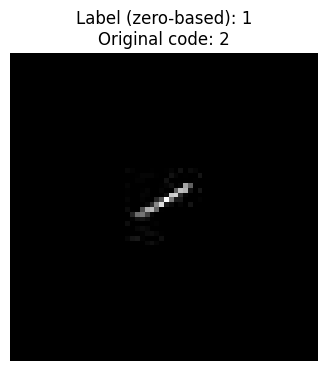

In [25]:
import random
# pick random sample idx
idx = random.randint(0, len(train_dataset) - 1)

img, label = train_dataset[idx]
img_np = img.squeeze(0).numpy() 

plt.figure(figsize=(4, 4))
plt.imshow(img_np, cmap='gray')  # clip in case of slight float errors
plt.axis("off")
plt.title(f"Label (zero-based): {label}\nOriginal code: {label + 1}")
plt.show()

In [11]:
img.shape

torch.Size([1, 64, 64])

# CNN class

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import warnings

# Same activation dictionary you used
ACTIVATIONS = {
    "sigmoid": nn.Sigmoid(),
    "relu": nn.ReLU(),
    "tanh": nn.Tanh(),
    "leakyrelu": nn.LeakyReLU(),
    "gelu": nn.GELU(),
}

class CNN(nn.Module):
    def __init__(
        self,
        input_channels,
        conv_channels,            # e.g. [32, 64, 128]
        kernel_sizes,             # e.g. [3, 3, 3] or single int
        stride=1,
        use_padding=True,
        padding_size=1,
        use_maxpooling=True,
        use_maxpooling_every=1,
        maxpooling_size=2,
        fc_layer_sizes=[],        # e.g. [256, 128, 15]
        input_size=(64, 64),      # H, W
        activation="relu"
    ):
        super().__init__()

        # ----------------------------------------------------
        # Validate activation
        # ----------------------------------------------------
        if activation not in ACTIVATIONS:
            raise ValueError(f"Unknown activation '{activation}'. "
                             f"Choose from: {list(ACTIVATIONS.keys())}")
        self.activation = ACTIVATIONS[activation]

        # ----------------------------------------------------
        # Normalize kernel size list
        # ----------------------------------------------------
        if isinstance(kernel_sizes, int):
            kernel_sizes = [kernel_sizes] * len(conv_channels)

        assert len(kernel_sizes) == len(conv_channels), \
            "kernel_sizes and conv_channels must have same length"

        self.convs = nn.ModuleList()
        current_c = input_channels
        h, w = input_size

        # ----------------------------------------------------
        # Build convolution + optional pooling layers
        # ----------------------------------------------------
        for i, out_c in enumerate(conv_channels):

            padding = padding_size if use_padding else 0
            ks = kernel_sizes[i]

            # Warning check for integer output
            if (h + 2 * padding - ks) % stride != 0:
                warnings.warn(
                    f"[Warning] Conv layer {i}: output height not integer. "
                    f"(h + 2*pad - ks) % stride != 0  --> "
                    f"({h} + 2*{padding} - {ks}) % {stride} != 0"
                )
            if (w + 2 * padding - ks) % stride != 0:
                warnings.warn(
                    f"[Warning] Conv layer {i}: output width not integer. "
                    f"({w} + 2*{padding} - {ks}) % {stride} != 0"
                )

            # Convolution layer
            self.convs.append(
                nn.Conv2d(current_c, out_c, kernel_size=ks, stride=stride, padding=padding)
            )

            # Update feature map size
            h = (h + 2 * padding - ks) // stride + 1
            w = (w + 2 * padding - ks) // stride + 1

            # Insert pooling if needed
            if use_maxpooling and (i + 1) % use_maxpooling_every == 0:
                self.convs.append(nn.MaxPool2d(maxpooling_size))
                h //= maxpooling_size
                w //= maxpooling_size

            current_c = out_c

        # ----------------------------------------------------
        # Flattened feature dimension after all convs
        # ----------------------------------------------------
        self.feature_dim = current_c * h * w

        # ----------------------------------------------------
        # Build fully connected layers
        # ----------------------------------------------------
        layers = []
        prev_dim = self.feature_dim

        for size in fc_layer_sizes:
            layers.append(nn.Linear(prev_dim, size))
            layers.append(self.activation)
            prev_dim = size

        self.fc = nn.Sequential(*layers) if layers else nn.Identity()

    # --------------------------------------------------------
    # Forward pass
    # --------------------------------------------------------
    def forward(self, x):
        for layer in self.convs:
            if isinstance(layer, nn.Conv2d):
                x = self.activation(layer(x))
            else:
                x = layer(x)

        x = x.view(x.size(0), -1)
        return self.fc(x)


# Training

In [40]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, CosineAnnealingLR
import numpy as np

In [42]:
seed = 123
random.seed(seed)
np.random.seed(seed)

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Hyperparameters ---
batch_size = 32
epochs = 50
learning_rate = 0.001

# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- model-specific hyperparameters ---
input_channels=1
conv_channels=[64, 128, 256]
kernel_sizes=5
use_padding=True
padding_size=1
use_maxpooling=True
use_maxpooling_every=1
fc_layer_sizes=[256, 15] # output 15 class
input_size=(64, 64)
activation="relu"

# --- Model ---
model = CNN(
    input_channels=input_channels,
    conv_channels=conv_channels,
    kernel_sizes=kernel_sizes,
    use_padding=use_padding,
    padding_size=padding_size,
    use_maxpooling=use_maxpooling,
    use_maxpooling_every=use_maxpooling_every,
    fc_layer_sizes=fc_layer_sizes,
    input_size=input_size,
    activation=activation
)
model.to(device)

# --- Loss and optimizer ---
criterion = nn.CrossEntropyLoss()  # good for multi-class classification
# optimizer = optim.Adam(model.parameters(), lr=learning_rate)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)  # halve LR every 20 epochs


# --- Training loop ---
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step()
    train_loss = running_loss / total
    train_acc = correct / total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    

    # --- Validation / Testing ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss /= total
    val_acc = correct / total
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(f"Epoch [{epoch}/{epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Using device: cuda
Epoch [1/50] Train Loss: 2.4096, Train Acc: 0.1876 | Val Loss: 2.2679, Val Acc: 0.1942
Epoch [2/50] Train Loss: 2.2723, Train Acc: 0.1956 | Val Loss: 2.2978, Val Acc: 0.1987
Epoch [3/50] Train Loss: 2.1855, Train Acc: 0.2272 | Val Loss: 2.1457, Val Acc: 0.2551
Epoch [4/50] Train Loss: 2.0783, Train Acc: 0.2586 | Val Loss: 2.0735, Val Acc: 0.2560
Epoch [5/50] Train Loss: 2.0438, Train Acc: 0.2623 | Val Loss: 2.0481, Val Acc: 0.2591
Epoch [6/50] Train Loss: 2.0278, Train Acc: 0.2638 | Val Loss: 2.0381, Val Acc: 0.2609
Epoch [7/50] Train Loss: 2.0279, Train Acc: 0.2645 | Val Loss: 2.0221, Val Acc: 0.2622
Epoch [8/50] Train Loss: 2.0165, Train Acc: 0.2643 | Val Loss: 2.0479, Val Acc: 0.2560
Epoch [9/50] Train Loss: 2.0098, Train Acc: 0.2653 | Val Loss: 2.0329, Val Acc: 0.2627
Epoch [10/50] Train Loss: 2.0050, Train Acc: 0.2651 | Val Loss: 2.0228, Val Acc: 0.2627
Epoch [11/50] Train Loss: 1.9933, Train Acc: 0.2658 | Val Loss: 2.0111, Val Acc: 0.2627
Epoch [12/50] Train Lo

KeyboardInterrupt: 

In [34]:
def plot_losses(train_losses, val_losses):
    """
    Plots training and test losses on the same figure.
    
    train_losses: list of floats
    test_losses:  list of floats
    """
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss", marker='o')
    plt.plot(val_losses, label="Val Loss", marker='s')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()

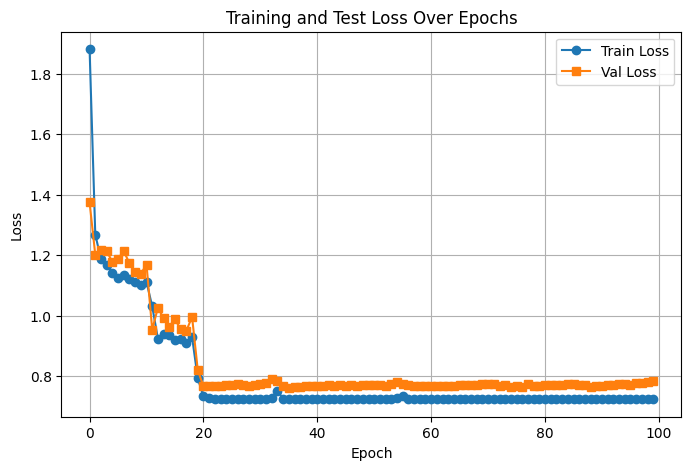

In [35]:
plot_losses(train_loss_history, val_loss_history)

# Performance evaluation

In [59]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def get_predictions_and_confusion(model, test_dataset, batch_size=64):
    """
    Get predictions for the entire test dataset and plot a confusion matrix.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_labels = []
    all_preds = []
    test_loss = 0.0
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)

            all_labels.append(labels.cpu())
            all_preds.append(preds.cpu())
            
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    test_loss /= total
    test_acc = correct / total

    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    # Concatenate all batches
    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()

    # print(all_labels.shape)

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(15))

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.arange(15), yticklabels=np.arange(15))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    return all_labels, all_preds, cm

Test Loss: 0.8014, Test Acc: 0.7876


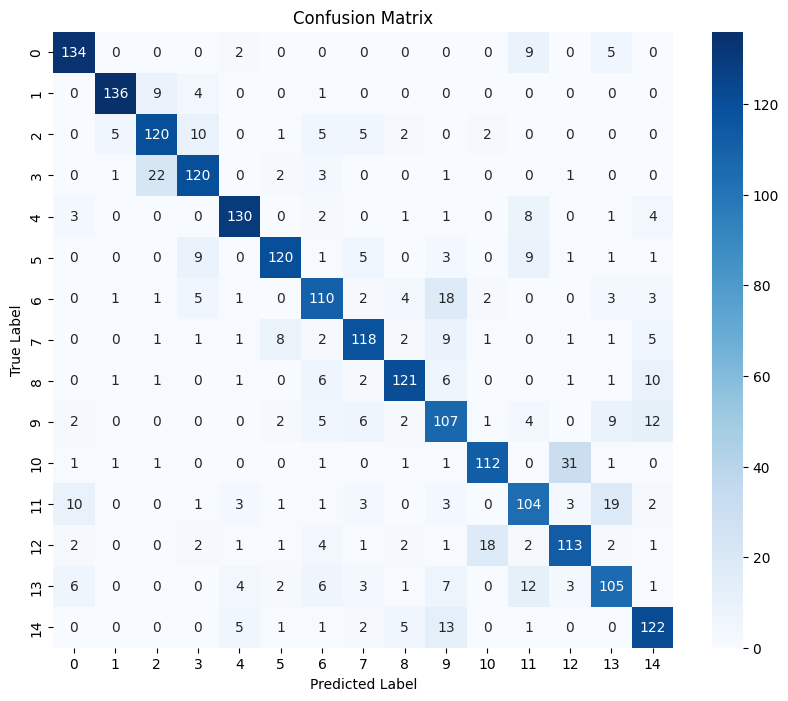

In [60]:
all_labels, all_preds, cm = get_predictions_and_confusion(model, test_dataset)